## City-Wide Demand DF

In [19]:
import pandas as pd

demand_df = pd.read_csv("/Users/ikmalbasirun/Documents/GitHub/NYC_Transportation_Demand/data/processed/transport_demand_dec2024.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ikmalbasirun/Documents/GitHub/NYC_Transportation_Demand/data/processed/transport_demand_dec2024.csv'

In [43]:
bus_df = pd.read_csv("/Users/ikmalbasirun/Documents/GitHub/NYC_Transportation_Demand/data/raw/MTA_Bus_Hourly_Ridership__2020-2024_20250415.csv")
subway_df = pd.read_csv("/Users/ikmalbasirun/Documents/GitHub/NYC_Transportation_Demand/data/raw/MTA_Subway_Hourly_Ridership__2020-2024_20250415.csv")

In [458]:
demand_df.head(10)

,date,hour,service_provider,LocationID,demand,weather_description
0,2024-12-01,0,Lyft,3,9,clear
1,2024-12-01,0,Lyft,3,9,clear
2,2024-12-01,0,Lyft,3,9,clear
3,2024-12-01,0,Lyft,3,9,clear
4,2024-12-01,0,Lyft,3,9,clear
5,2024-12-01,0,Lyft,3,9,clear
6,2024-12-01,0,Lyft,3,9,clear
7,2024-12-01,0,Lyft,3,9,clear
8,2024-12-01,0,Lyft,3,9,clear
9,2024-12-01,0,Lyft,3,9,mainly_clear


In [459]:
#demand_df.drop(columns='LocationID', inplace=True)

Re-aggregates data without 'LocationID'

In [460]:
#demand_df = demand_df.groupby(['date','hour','service_provider']).size().reset_index(name='demand')

In [461]:
demand_df.head(10)

,date,hour,service_provider,LocationID,demand,weather_description
0,2024-12-01,0,Lyft,3,9,clear
1,2024-12-01,0,Lyft,3,9,clear
2,2024-12-01,0,Lyft,3,9,clear
3,2024-12-01,0,Lyft,3,9,clear
4,2024-12-01,0,Lyft,3,9,clear
5,2024-12-01,0,Lyft,3,9,clear
6,2024-12-01,0,Lyft,3,9,clear
7,2024-12-01,0,Lyft,3,9,clear
8,2024-12-01,0,Lyft,3,9,clear
9,2024-12-01,0,Lyft,3,9,mainly_clear


Bus Transform

In [46]:
bus_df.head(10)

,transit_timestamp,bus_route,ridership,payment_method,fare_class_category,transfers
0,12/01/2024 12:00:00 AM,X12,0,omny,Metrocard - Other,0
1,12/01/2024 12:00:00 AM,B49,0,metrocard,OMNY - Other,0
2,12/01/2024 12:00:00 AM,Q31,0,omny,Metrocard - Students,0
3,12/01/2024 12:00:00 AM,S94,0,omny,OMNY - Other,0
4,12/01/2024 12:00:00 AM,X17A,0,omny,OMNY - Fair Fare,0
5,12/01/2024 12:00:00 AM,BX18A,0,omny,OMNY - Students,0
6,12/01/2024 12:00:00 AM,X64,0,omny,OMNY - Students,0
7,12/01/2024 12:00:00 AM,QM5,0,omny,OMNY - Other,0
8,12/01/2024 12:00:00 AM,X64,0,metrocard,OMNY - Fair Fare,0
9,12/01/2024 12:00:00 AM,Q06,0,omny,OMNY - Other,0


In [47]:
bus_df['transit_timestamp'] = pd.to_datetime(bus_df['transit_timestamp'])

bus_df['hour'] = bus_df['transit_timestamp'].dt.hour
bus_df['date'] = pd.to_datetime(bus_df['transit_timestamp'].dt.date)

bus_df = bus_df.drop(columns=['fare_class_category', 'transfers', 'payment_method','transit_timestamp'])

bus_df = bus_df.groupby(['date', 'hour', 'bus_route']).sum('ridership').reset_index()

bus_df.rename(
    columns={'ridership':'demand','bus_route':'LocationID'},
    inplace=True
    )

bus_df['service_provider'] = 'Bus'

bus_df.head(10)

/var/folders/0b/920j3nln4yn8tz94rztlp5900000gn/T/ipykernel_15614/2872314624.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bus_df['transit_timestamp'] = pd.to_datetime(bus_df['transit_timestamp'])


,date,hour,LocationID,demand,service_provider
0,2024-12-01,0,B1,24,Bus
1,2024-12-01,0,B100,3,Bus
2,2024-12-01,0,B101,0,Bus
3,2024-12-01,0,B103,38,Bus
4,2024-12-01,0,B106,0,Bus
5,2024-12-01,0,B11,21,Bus
6,2024-12-01,0,B111,0,Bus
7,2024-12-01,0,B12,24,Bus
8,2024-12-01,0,B13,18,Bus
9,2024-12-01,0,B14,4,Bus


In [25]:
subway_df.head(10)

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,Georeference
0,12/01/2024 12:00:00 AM,subway,185,Liberty Av (C),Brooklyn,metrocard,Metrocard - Other,1,0,40.674540,-73.896545,POINT (-73.896545 40.67454)
1,12/01/2024 12:00:00 AM,subway,192,Rockaway Blvd (A),Queens,metrocard,Metrocard - Unlimited 30-Day,3,0,40.680428,-73.843860,POINT (-73.84386 40.680428)
2,12/01/2024 12:00:00 AM,subway,277,"7 Av (E,B,D)",Manhattan,omny,OMNY - Full Fare,155,1,40.762863,-73.981636,POINT (-73.981636 40.762863)
3,12/01/2024 12:00:00 AM,subway,59,9 Av (D),Brooklyn,omny,OMNY - Full Fare,12,2,40.646294,-73.994320,POINT (-73.99432 40.646294)
4,12/01/2024 12:00:00 AM,subway,314,66 St-Lincoln Center (1),Manhattan,metrocard,Metrocard - Seniors & Disability,3,0,40.773440,-73.982210,POINT (-73.98221 40.77344)
5,12/01/2024 12:00:00 AM,subway,283,Greenpoint Av (G),Brooklyn,omny,OMNY - Full Fare,42,1,40.731354,-73.954450,POINT (-73.95445 40.731354)
6,12/01/2024 12:00:00 AM,subway,283,Greenpoint Av (G),Brooklyn,omny,OMNY - Students,3,0,40.731354,-73.954450,POINT (-73.95445 40.731354)
7,12/01/2024 12:00:00 AM,subway,45,Beverley Rd (Q),Brooklyn,metrocard,Metrocard - Seniors & Disability,1,0,40.644030,-73.964490,POINT (-73.96449 40.64403)
8,12/01/2024 12:00:00 AM,subway,456,61 St-Woodside (7),Queens,omny,OMNY - Students,3,0,40.745630,-73.902985,POINT (-73.902985 40.74563)
9,12/01/2024 12:00:00 AM,subway,319,28 St (1),Manhattan,omny,OMNY - Full Fare,69,0,40.747215,-73.993360,POINT (-73.99336 40.747215)


Subway Transformation

In [26]:
subway_df['transit_timestamp'] = pd.to_datetime(subway_df['transit_timestamp'])

subway_df['hour'] = subway_df['transit_timestamp'].dt.hour
subway_df['date'] = pd.to_datetime(subway_df['transit_timestamp'].dt.date)

subway_df = subway_df.drop(columns=['fare_class_category', 'transfers', 'latitude','longitude','payment_method','transit_timestamp',
                                    'station_complex', 'borough', 'Georeference'])

subway_df = subway_df.groupby(['date', 'hour','station_complex_id']).sum('ridership').reset_index()

subway_df.rename(
    columns={'ridership':'demand', 
             'transit_mode':'service_provider',
             'station_complex_id':'LocationID'},
    inplace=True
    )

subway_df['LocationID'] = subway_df['LocationID'].astype('category')
    
subway_df['service_provider'] = 'Subway'

/var/folders/0b/920j3nln4yn8tz94rztlp5900000gn/T/ipykernel_15614/254866911.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subway_df['transit_timestamp'] = pd.to_datetime(subway_df['transit_timestamp'])


In [27]:
subway_df.dtypes

date                datetime64[ns]
hour                         int32
LocationID                category
demand                       int64
service_provider            object
dtype: object

In [31]:
subway_df.sample(10)

,date,hour,LocationID,demand,service_provider
153494,2024-12-16,4,194,15,Subway
76672,2024-12-08,14,359,475,Subway
128054,2024-12-13,15,441,516,Subway
55467,2024-12-06,10,70,108,Subway
273025,2024-12-27,22,403,426,Subway
182479,2024-12-19,0,201,2,Subway
98731,2024-12-10,18,605,1582,Subway
135851,2024-12-14,10,177,296,Subway
30607,2024-12-04,0,351,5,Subway
88917,2024-12-09,19,46,74,Subway


Merge Subway and Bus DFs

In [468]:
demand_df['date'] = pd.to_datetime(demand_df['date'])

# change type to 'category'
demand_df['LocationID'].astype('category')

0           3
1           3
2           3
3           3
4           3
         ... 
885331    260
885332    261
885333    262
885334    263
885335    265
Name: LocationID, Length: 885336, dtype: category
Categories (263, int64): [1, 2, 3, 4, ..., 262, 263, 264, 265]

In [469]:
subway_df.dtypes

date                datetime64[ns]
hour                         int32
LocationID                category
demand                       int64
service_provider            object
dtype: object

In [470]:
demand_with_bus_df = demand_df.merge(
    bus_df,
    how='outer',
    on=['date','hour','service_provider', 'LocationID', 'demand'],
    
)

demand_with_bus_df.head(10)

,date,hour,service_provider,LocationID,demand,weather_description
0,2024-12-01,0,Bus,B1,24,NaN
1,2024-12-01,0,Bus,B100,3,NaN
2,2024-12-01,0,Bus,B101,0,NaN
3,2024-12-01,0,Bus,B103,38,NaN
4,2024-12-01,0,Bus,B106,0,NaN
5,2024-12-01,0,Bus,B11,21,NaN
6,2024-12-01,0,Bus,B111,0,NaN
7,2024-12-01,0,Bus,B12,24,NaN
8,2024-12-01,0,Bus,B13,18,NaN
9,2024-12-01,0,Bus,B14,4,NaN


In [471]:
final_demand_df = demand_with_bus_df.merge(
    subway_df,
    how='outer',
    on=['date','hour','service_provider', 'LocationID', 'demand'],
    
)

final_demand_df.head(10)

,date,hour,service_provider,LocationID,demand,weather_description
0,2024-12-01,0,Bus,B1,24,NaN
1,2024-12-01,0,Bus,B100,3,NaN
2,2024-12-01,0,Bus,B101,0,NaN
3,2024-12-01,0,Bus,B103,38,NaN
4,2024-12-01,0,Bus,B106,0,NaN
5,2024-12-01,0,Bus,B11,21,NaN
6,2024-12-01,0,Bus,B111,0,NaN
7,2024-12-01,0,Bus,B12,24,NaN
8,2024-12-01,0,Bus,B13,18,NaN
9,2024-12-01,0,Bus,B14,4,NaN


In [48]:
import pandas as pd
final_demand_df = pd.read_csv("/Users/ikmalbasirun/Documents/GitHub/NYC_Transportation_Demand/data/processed/demand_dec2024_withWeather.csv")

In [69]:
final_demand_df.sample(20)

,date,hour,service_provider,day_of_week,LocationID,demand,weather_description
657313,2024-12-20,9,Uber,4,62,109,overcast
601324,2024-12-18,18,Bus,2,X22A,0,clear
430887,2024-12-13,17,Uber,4,240,16,clear
11794,2024-12-01,8,Subway,6,244,84,clear
87666,2024-12-03,14,Subway,1,149,91,clear
652239,2024-12-20,6,Lyft,4,138,2,overcast
273368,2024-12-09,2,Subway,0,157,2,clear
513751,2024-12-16,4,Lyft,0,242,7,light_drizzle
130457,2024-12-04,20,Taxi,2,193,4,overcast
474734,2024-12-15,0,Subway,6,450,103,clear


EDA

<Axes: xlabel='date', ylabel='demand'>

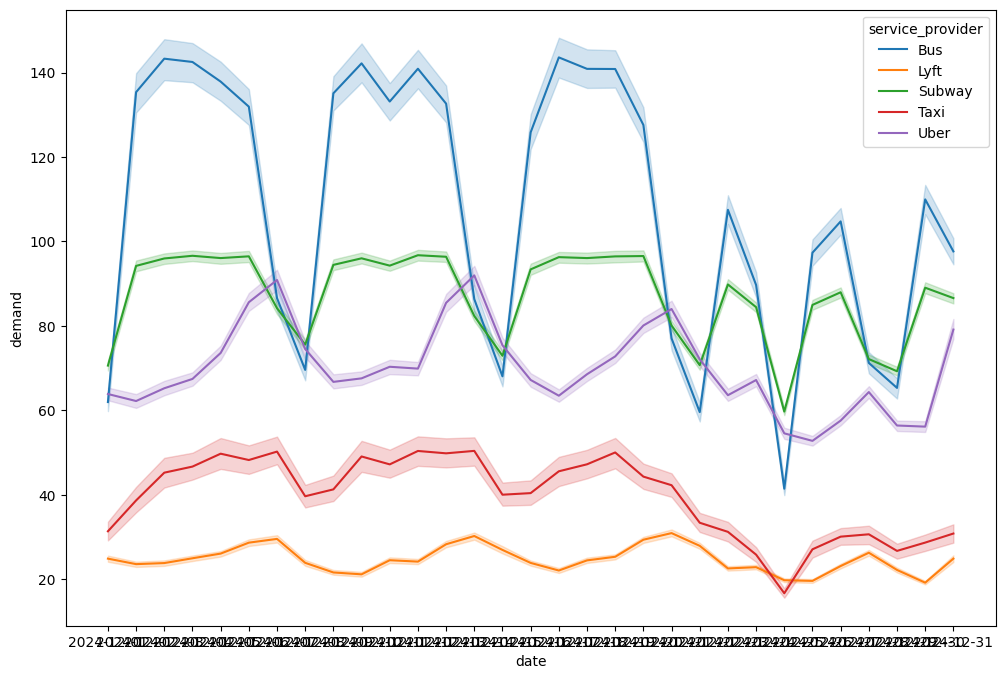

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.lineplot(data=final_demand_df, x='date', y='demand', hue='service_provider')

<Axes: xlabel='hour', ylabel='demand'>

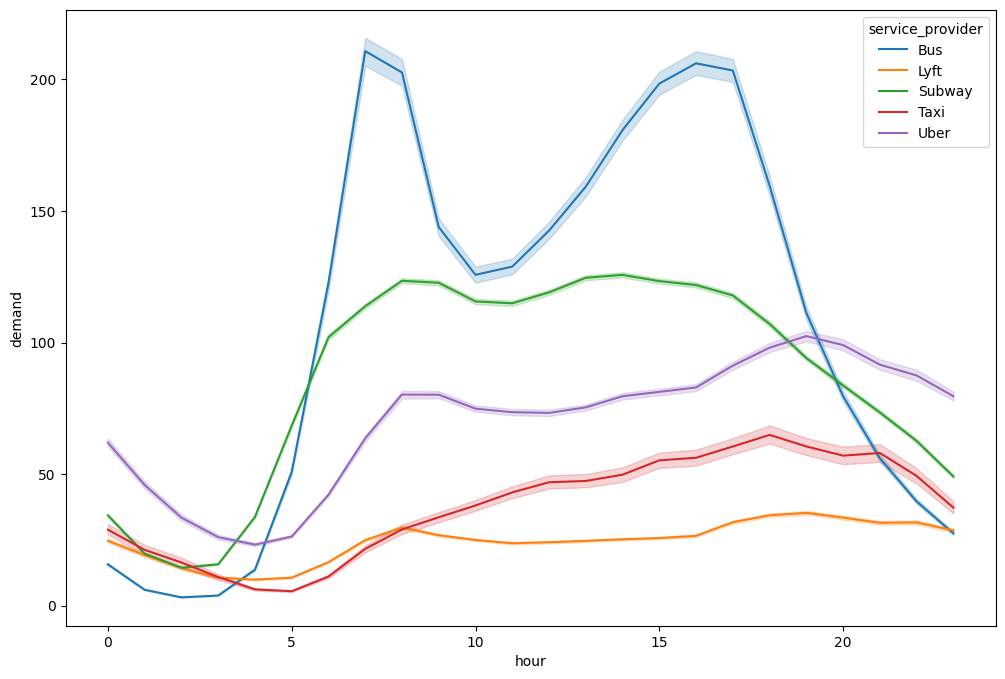

In [55]:
plt.figure(figsize=(12,8))
sns.lineplot(data=final_demand_df, x='hour', y='demand', hue='service_provider')

KeyError: 'y'

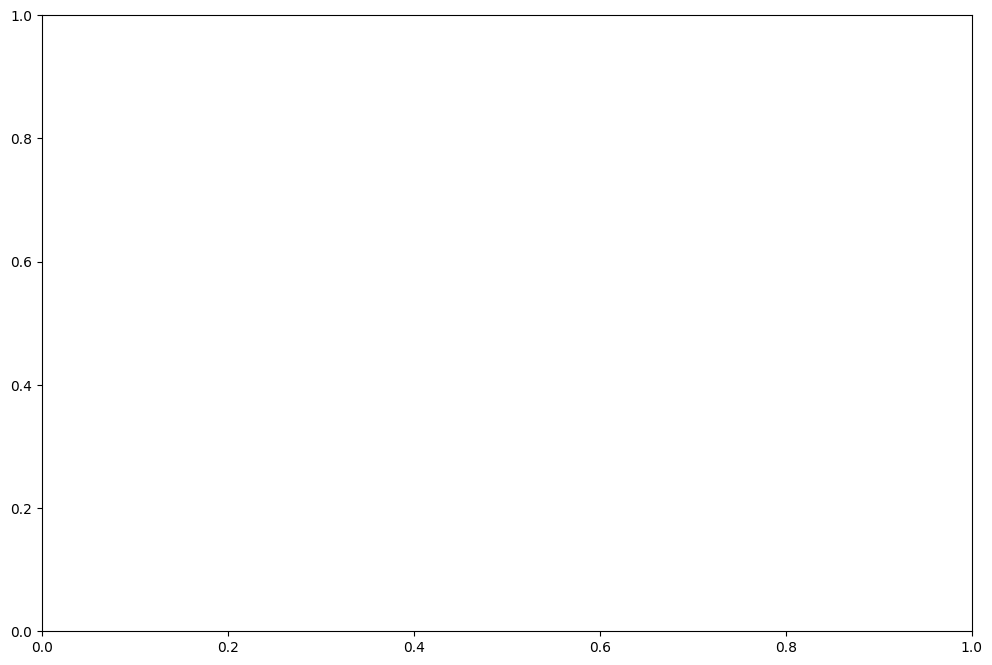

In [71]:
plt.figure(figsize=(12,8))
sns.lineplot(x=final_demand_df['hour'], y=final_demand_df.loc[final_demand_df['service_provider'] == 'bus','demand'])